# FeatureUnion & Target Transform
**ShipmentSure — Predicting On-Time Delivery**

- FeatureUnion combining PCA path + SelectKBest path (complementary views)
- TransformedTargetRegressor for log-scale regression
- train_test_split for reproducible evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('Reached.on.Time_Y.N', axis=1)
y = df_encoded['Reached.on.Time_Y.N']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (800, 15), Test: (200, 15)


In [3]:
# Scale first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# FeatureUnion: PCA path + SelectKBest path
feature_union = FeatureUnion([
    ('pca_path', PCA(n_components=5)),
    ('kbest_path', SelectKBest(f_classif, k=5))
])

X_train_union = feature_union.fit_transform(X_train_scaled, y_train)
X_test_union = feature_union.transform(X_test_scaled)

print(f"FeatureUnion output shape: {X_train_union.shape}")
print("Note: PCA contributes 5 components + SelectKBest contributes 5 = 10 features total")

FeatureUnion output shape: (800, 10)
Note: PCA contributes 5 components + SelectKBest contributes 5 = 10 features total


In [5]:
# Train LogisticRegression on FeatureUnion output
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_union, y_train)
y_pred = lr.predict(X_test_union)

acc = accuracy_score(y_test, y_pred)
print(f"LogisticRegression on FeatureUnion features: Accuracy = {acc:.4f}")

LogisticRegression on FeatureUnion features: Accuracy = 0.5750


In [6]:
# TransformedTargetRegressor — train in log-space, predict in original scale
# Applied to the cost column (regression demonstration)
X_reg = df[['Weight_in_gms', 'Discount_offered', 'Customer_care_calls', 'Prior_purchases']].values
y_reg = df['Cost_of_the_Product'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

tt_reg = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log1p,
    inverse_func=np.expm1
)
tt_reg.fit(X_train_r, y_train_r)
preds = tt_reg.predict(X_test_r)

mae = np.mean(np.abs(preds - y_test_r))
print(f"TransformedTargetRegressor (log-scale regression) — MAE: {mae:.2f}")

TransformedTargetRegressor (log-scale regression) — MAE: 55.18


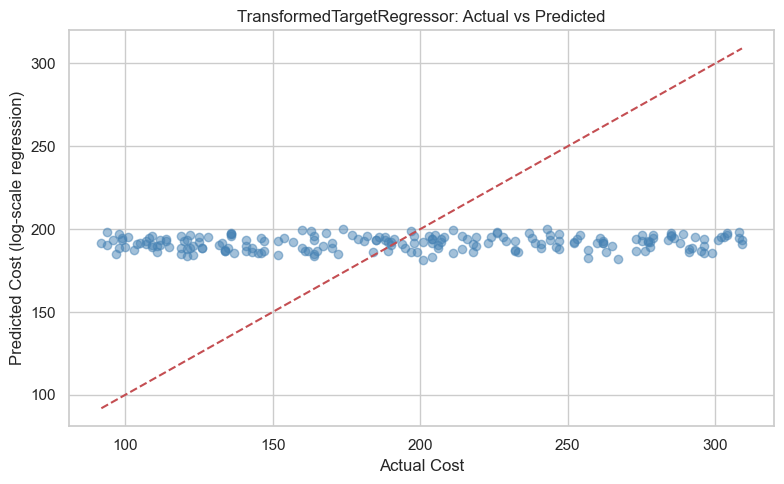

In [7]:
# Compare predictions vs actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, preds, alpha=0.5, color='steelblue')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.xlabel('Actual Cost')
plt.ylabel('Predicted Cost (log-scale regression)')
plt.title('TransformedTargetRegressor: Actual vs Predicted')
plt.tight_layout()
plt.show()